In [2]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Generate a clean synthetic retail dataset automatically
np.random.seed(42)
items = ['Laptop', 'Wireless Mouse', 'Keyboard', 'HDMI Cable', 'Monitor', 'Headphones', 'USB Drive', 'Webcam']
data_list = []

for i in range(1, 501):  # 500 grocery transactions
    transaction_items = np.random.choice(items, size=np.random.randint(2, 5), replace=False)
    for item in transaction_items:
        data_list.append([i, item])

df = pd.DataFrame(data_list, columns=['Transaction_ID', 'Item'])

print("--- First 5 rows of Transaction Data ---")
print(df.head())

# 2. Preprocess data into a binary matrix format for Apriori
basket = (df.groupby(['Transaction_ID', 'Item'])['Item']
          .count().unstack().reset_index().fillna(0)
          .set_index('Transaction_ID'))

# Convert counts to binary values (True/False or 1/0)
basket = basket.map(lambda x: 1 if x > 0 else 0)

# 3. Apply the Apriori Algorithm to find frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)

# 4. Generate the final Association Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Sort rules to show the strongest connections first
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print("\n--- Strongest Product Associations Found ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

--- First 5 rows of Transaction Data ---
   Transaction_ID            Item
0               1          Webcam
1               1  Wireless Mouse
2               1      Headphones
3               1          Laptop
4               2          Laptop

--- Strongest Product Associations Found ---
    antecedents   consequents  support  confidence      lift
0   (USB Drive)    (Keyboard)    0.130    0.365169  1.025754
1    (Keyboard)   (USB Drive)    0.130    0.365169  1.025754
2  (Headphones)   (USB Drive)    0.132    0.360656  1.013078
3   (USB Drive)  (Headphones)    0.132    0.370787  1.013078


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

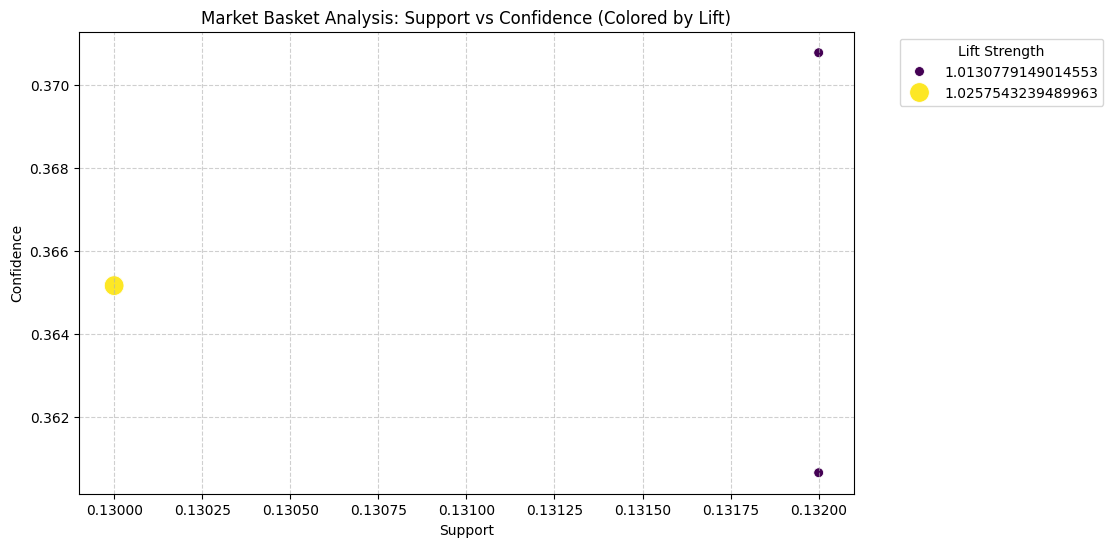

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the rules using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rules['support'], y=rules['confidence'], hue=rules['lift'], palette='viridis', size=rules['lift'], sizes=(50, 200))
plt.title('Market Basket Analysis: Support vs Confidence (Colored by Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Lift Strength')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()